### **Table of Contents**

1. [Introduction](#1-introduction)

    - [Assignment Description](#assignment-description)
    - [Imports](#imports)


2. [Exploratory Data Analysis (EDA)](#2-exploratory-data-analysis-eda)

    - [Basics](#basics)
    - [Distribution of Numerical Features (Histogram)](#distribution-of-numerical-features-plot)
    - [Data Validation](#data-validation)
    - [Imbalanced Dataset](#imbalanced-dataset)
    - [EDA Summary](#eda-summary)


3. [Data Processing](#3-data-processing)

    - [Invalid Values](#invalid-values)
    - [Missing Values](#missing-values)


4. [Prepairing Data for Modelling](#4-prepairing-data-for-modelling)

    - [Defining Features & Target](#defining-features--target)
    - [Feature Encoding](#feature-encoding)


5. [Baseline Models](#5-baseline-models)

    - [Baseline Models - Building & Training](#baseline-models---building--training)
    - [Baseline Models - Evaluation](#baseline-models---evaluation)


6. [Tuned Models](#6-tuned-models)

    - [Tuned Models - Building & Training](#tuned-models---buildning--training)
    - [Tuned Models - Results](#tuned-models---results)
    - [Tuned Models - Evaluation](#tuned-models---evaluation)


7. [Confusion Matrix Analysis](#7-confusion-matrix)

    - [Matrix Plotting](#matrix-plotting)
    - [Matrix Analysis](#matrix-analysis)


8. [Model Selection](#8-model-selection)


9. [Feature Importance & Insights](#9-feature-importance--insights)

    - [Top 10 Features - Plots](#top-10-features-plots)
    - [Feature Importance - Insights](#feature-importance---insights)


10. [Presentation for Management](#10-presentation-for-management)

    - [Plot for Presentation](#plot-for-presentation)
    - [Presentation](#presentation)

---

## **1. Introduction**

### Assignment Description


Several years ago, the management of e-commerce giant KokoBananas completely switched to digital marketing and sales. It turned out to be a wise choice. Over time, however, as the digital competence of competitors has increased, digital competition has also gotten tougher. Their industry, the cosmetics and health-oriented one, is particularly vulnerable. The management has now realised that the key to success in e-commerce is user experience. 

One problem they've noticed is that too many visitors on their website do not convert, i.e. do not buy anything. In order to understand what a good user experience is, the company first needs to understand which customers actually convert and buy. 

You've been tasked with initially developing an 'AI model' that can predict whether a customer session will result in a purchase or not, in real time. 

To help you, you have historical data on customer sessions containing conditions that apply to each session, as well as whether each session leads to a purchase or not. The ambition and hope is that the results of this analysis can be applied to future customers, in real time, in order to quickly identify the customers who actually order products. 

Once you've done your analysis, you should then present your conclusions to the company management in an understandable way. Both strengths and weaknesses in your predictions need to be highlighted, so that the management and the company can make correct decisions based on the decision support generated by the model.

----

**NOTE:** The dataset was provided by my teacher, however, it's a modified version of this [*dataset*](https://www.kaggle.com/datasets/henrysue/online-shoppers-intention/data).

----

### Imports

In [1]:
# --- IMPORTS ---

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

from sklearn.metrics import confusion_matrix

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

## **2. Exploratory Data Analysis (EDA)**

### Basics

In [2]:
pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', None)

data_df = pd.read_csv('project_data.csv')

data_df.head(10)
# Checking that the dataframe looks right

,Unnamed: 0,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,NaN,1.0,1,Returning_Visitor,False,False
1,1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.0,0.0,Feb,2,2.0,NaN,2,Returning_Visitor,False,False
2,2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,4,1.0,NaN,3,Returning_Visitor,False,False
3,3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.0,0.0,Feb,3,2.0,2.0,4,Returning_Visitor,False,False
4,4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,Feb,3,3.0,1.0,4,Returning_Visitor,True,False
5,5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2.0,1.0,3,Returning_Visitor,False,False
6,6,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.4,Feb,2,4.0,3.0,3,Returning_Visitor,False,False
7,7,1,0.0,0,0.0,0,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,2.0,1.0,5,Returning_Visitor,True,False
8,8,0,0.0,0,0.0,2,37.000000,0.000000,0.100000,0.0,0.8,Feb,2,2.0,2.0,3,Returning_Visitor,False,False
9,9,0,0.0,0,0.0,3,738.000000,0.000000,0.022222,0.0,0.4,Feb,2,4.0,1.0,2,Returning_Visitor,False,False


In [3]:
# Removing old index column
data_df = data_df.drop(columns=['Unnamed: 0'])

# I'm doing this immediately as it will just add clutter to the EDA 

In [4]:
data_df.shape

(12330, 18)

In [5]:
data_df.info()

# We have some weird datatypes - I would have expected 'Weekend' and 'Revenue' to be ints or bools (as they store binary data)

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12207 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12146 non-null  float64
 13  Region                   12084 non-null  float64
 14  TrafficType              12330 no

In [6]:
data_df.isnull().sum()

# We are missing some values - most concerningly in the 'Revenue' column (which will act as the target).

Administrative               0
Administrative_Duration      0
Informational                0
Informational_Duration       0
ProductRelated               0
ProductRelated_Duration      0
BounceRates                  0
ExitRates                    0
PageValues                   0
SpecialDay                 123
Month                        0
OperatingSystems             0
Browser                    184
Region                     246
TrafficType                  0
VisitorType                  0
Weekend                      0
Revenue                    147
dtype: int64

### Distribution of Numerical Features (plot)

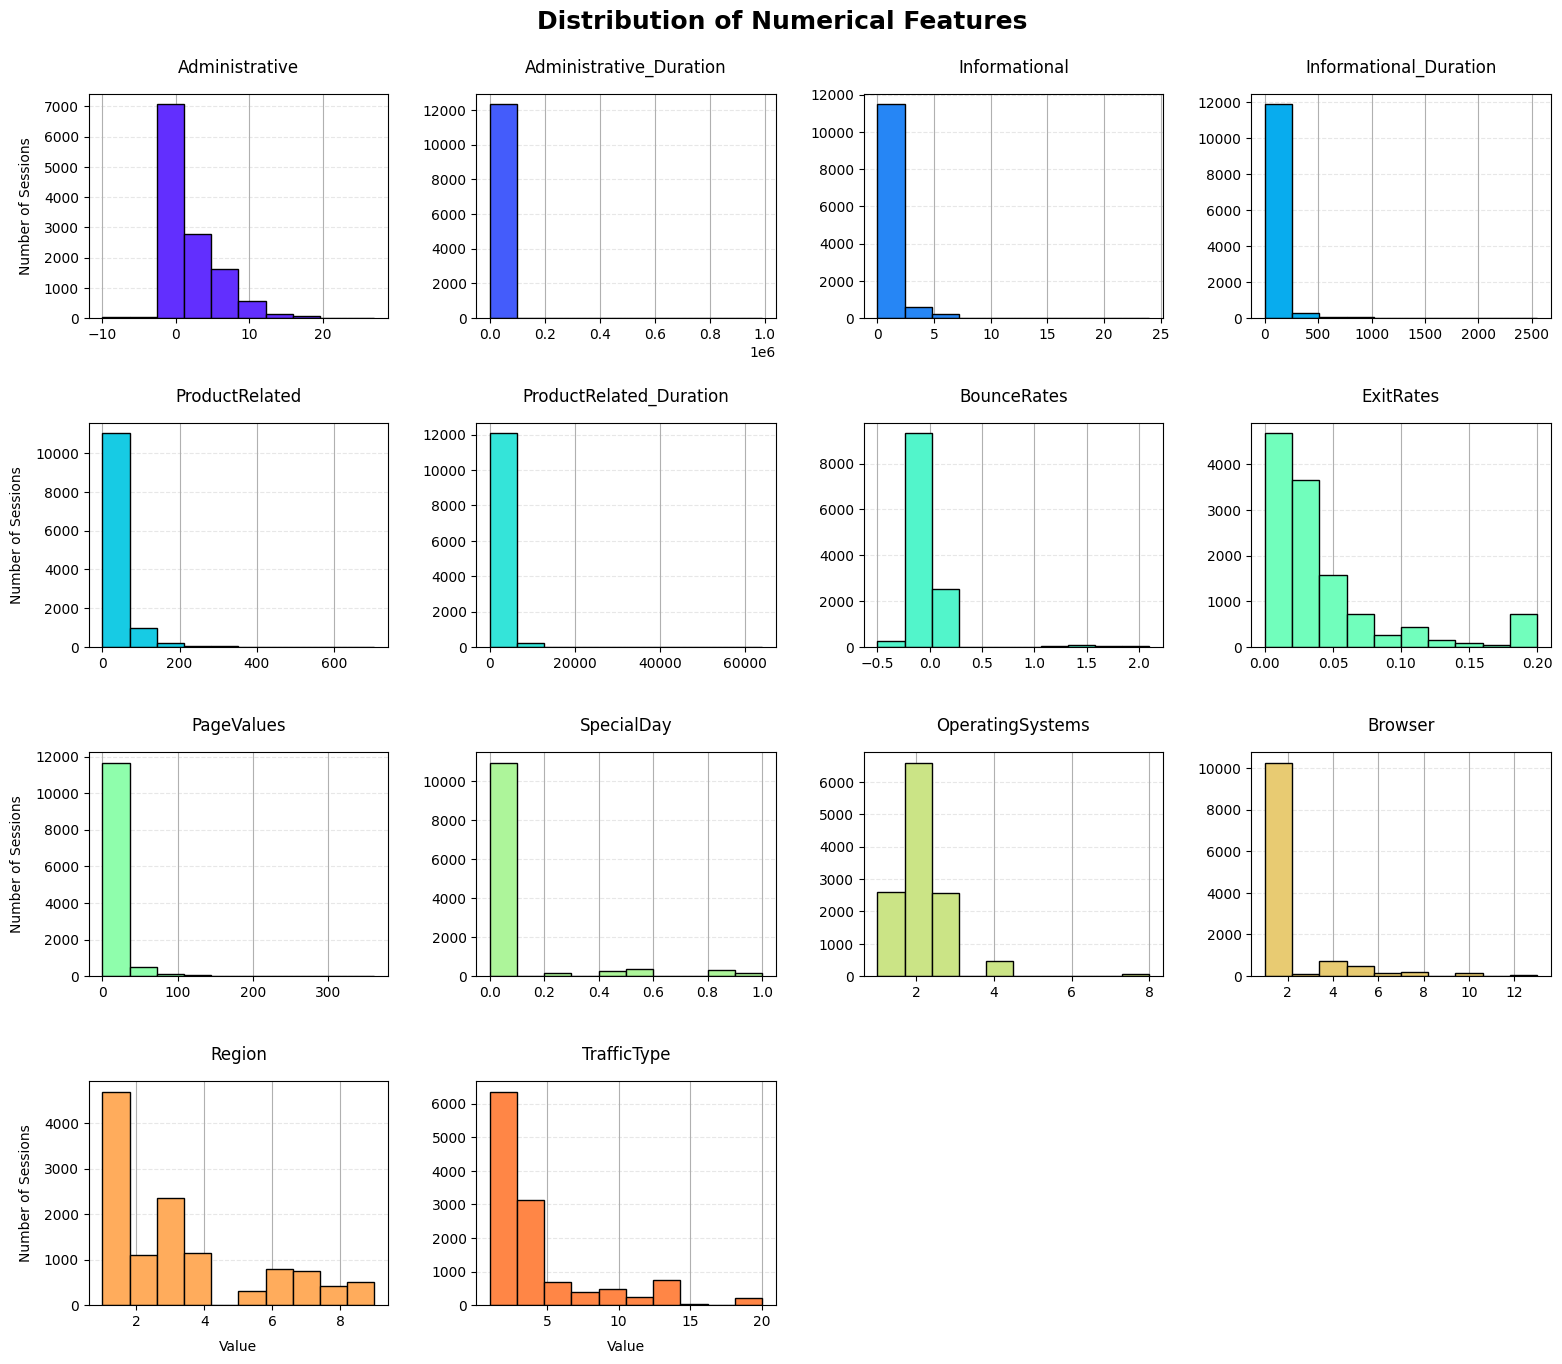

In [7]:
# Histogram plot
axes = data_df.hist(
    figsize=(16, 14), 
    edgecolor='black')

# Colour palette (one colour per subplot)
palette = sns.color_palette('rainbow', len(axes.flatten()))#[::-1] 

# Increase subplot title and tick size
for i, (ax, colour) in enumerate(zip(axes.flatten(), palette)):

    # Colour bars
    for patch in ax.patches:
        patch.set_facecolor(colour)

    # Titles and ticks
    ax.set_title(ax.get_title(), fontsize=12, pad=15)
    ax.tick_params(axis='both', labelsize=10)

    # Labels: only added to left column and bottom row to prevent visual clutter 
    if i % axes.shape[1] == 0:  # left column
        ax.set_ylabel("Number of Sessions", labelpad=8)
    
    if i >= len(axes.flatten()) - axes.shape[1]:  # bottom row
        ax.set_xlabel("Value", labelpad=8)

    # Grid styling    
    ax.set_axisbelow(True)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.suptitle('Distribution of Numerical Features', 
             fontsize=18, 
             fontweight='bold')

plt.tight_layout(pad=2.0)
plt.subplots_adjust(top=0.92)

plt.show()

From the histogram we can see:

- **'Administrative'** - negative values

Variable Information (from the website): *"'Administrative' represents the number of different types of pages visited by each visitor in that session and total time spent in each of these page categories".*

It's not logically possible to visit a ***negative*** number of pages, which makes any negative values in this column invalid. 


- **'BounceRates'** - values below $0$ and above $1$

Variable Information (from the website): *"The value of 'BounceRates' refers to the percentage of visitors who enter the site from that page and then leave ("bounce") without triggering any other requests to the analytics server during that session."*

The percentage is represented in decimal form and is supposed to be a number between $0$ and $1$. So, any values below $0$ or above $1$, are not logically possible, making the values invalid.


### Data Validation

In [8]:
# Data Validation

# Running a loop to check all of the unique values for each column 
for col in data_df.columns:
    print(f'\nColumn: {col}')
    print(data_df[col].unique())


Column: Administrative
[  0   1   2   4  12   3  10   6  -3  -8  -1   5   9  -7 -10   8  16  13
  11   7  -9  18  14  -5  17  19  15  -2  24  -6  -4  22  21  20  23  27
  26]

Column: Administrative_Duration
[  0.         53.         64.6       ... 167.9107143 305.125
 150.3571429]

Column: Informational
[ 0  1  2  4 16  5  3 14  6 12  7  9 10  8 11 24 13]

Column: Informational_Duration
[  0.   120.    16.   ... 547.75 368.25 211.25]

Column: ProductRelated
[  1   2  10  19   0   3  16   7   6  23  13  20   8   5  32   4  45  14
  52   9  46  15  22  11  12  36  42  27  90  18  38  17 128  25  30  21
  51  26  28  31  24  50  96  49  68  98  67  55  35  37  29  34  71  63
  87  40  33  54  64  75  39 111  81  61  47  44  88 149  41  79  66  43
 258  80  62  83 173  48  58  57  56  69  82  59 109 287  53  84  78 137
 113  89  65  60 104 129  77  74  93  76  72 194 140 110 132 115  73 328
 160  86 150  95 130 151 117 124 127 125 116 105  92 157 154 220 187 112
 131 159  94 204 142 206 

In [9]:
# for clearity I'm reprinting two columns with invalid values 
cols_to_highlight = ['Month', 'Weekend']

for col in cols_to_highlight:
    print(f'Unique values in {col}: {data_df[col].unique()}\n')

# 'Month' contains 'Turc' (invalid value), and 'Sep' & 'Sept' (we're also missing January and April)

# 'Weekend' contains 'Name:Zara' - invalid value

Unique values in Month: <StringArray>
[ 'Feb',  'Mar',  'May', 'Turc',  'Oct', 'June',  'Jul',  'Aug',  'Nov',
  'Sep', 'Sept',  'Dec']
Length: 12, dtype: str

Unique values in Weekend: <StringArray>
['False', 'True', 'Name:Zara']
Length: 3, dtype: str



In [10]:
# Checking that which numerical columns contains negative numbers 
for col in data_df.select_dtypes(include=['int64', 'float64']).columns:
    count = (data_df[col] < 0).sum()
    if count > 0: 
        print(f'{col}: {count} values below 0')


# Columns that should NOT contain any values above 1
cols_to_check = ['BounceRates', 'ExitRates', 'SpecialDay']

for col in cols_to_check:
    count = (data_df[col] > 1).sum()
    if count > 0:
        print(f'{col}: {count} values above 1')

Administrative: 123 values below 0
BounceRates: 363 values below 0
BounceRates: 246 values above 1


### Imbalanced Dataset

In [11]:
print(data_df['Revenue'].value_counts())
print(data_df['Revenue'].value_counts(normalize=True))

Revenue
False    10303
True      1880
Name: count, dtype: int64
Revenue
False    0.845687
True     0.154313
Name: proportion, dtype: float64


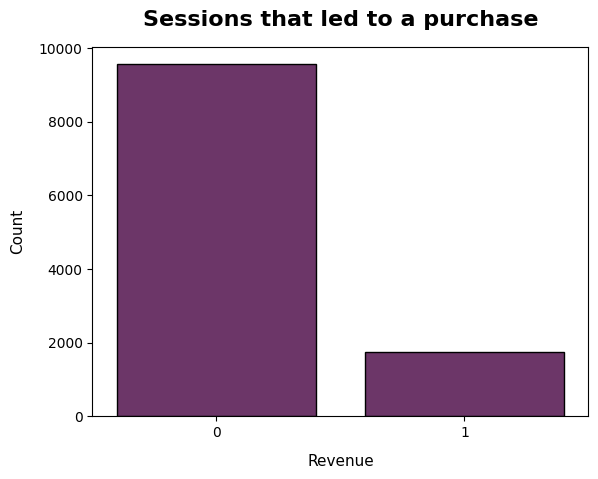

In [52]:
# Countplot of how many sessions led to a purchase 
sns.countplot(x='Revenue', data=data_df, color='#752d6f', edgecolor='black')

# Labels 
plt.title('Sessions that led to a purchase', size='16', weight='bold', pad=15)
plt.ylabel('Count', size=11, labelpad=10)
plt.xlabel('Revenue', size=11, labelpad=10)

plt.show()

When looking at the histogram from earlier, we can see that all of the numerical features mostly consist of values close to $0$. 


After checking the `value_counts()` of ‘Revenue’ and making a countplot, we can see that the dataset is, in fact, imbalanced; significantly more sessions did ***not*** lead to a purchase. This is an important insight for the later modelling. 

### EDA Summary

- Missing values in ‘SpecialDay’, ‘Browser’, ‘Region’, and ‘Revenue’. 

- Invalid values in: ‘Administrative’, ‘BounceRates’, ‘Month’, and ‘Weekend’. 

- Odd datatypes for ‘Weekend’ and ‘Revenue’ (especially ‘Revenue’ since object is a catch-all datatype in Pandas). 

- The dataset is imbalanced, which is something I need to keep in mind when training the models. 

----

[Back to Top ⇧](#table-of-contents)

---

## **3. Data Processing**

### Invalid Values

- **'Month'**

*'Sep'* and *'Sept'* refer to the same month, so I will standardise the two to prevent the model from treating them as different months. 

For the invalid value *'Turc'*, I decided to replace the value with `None` and then treat the data as missing values. 

When it came to handling the now missing values, I debated potentially going with probabilistic (distribution-based) imputation. That would preserve the dataset's overall distribution of months and ensure that no month is over-represented (which mode imputation likely would cause). However, using this method risks introducing bias and any real meaningful patterns between features could be diluted or destroyed. 

In the end, I decided to remove the rows with missing values, as this seemed to be the most reliable and transparent solution. 

In [13]:
# Standardising the data and replacing 'Turc' with None
data_df['Month'] = data_df['Month'].replace({
    'Sept': 'Sep',
    'Turc': None,
    
    'June': 'Jun'   # this is completely unnecessary, but it looks nicer if all months are 3 letters long 
})

In [14]:
# Removing rows with missing values
data_df = data_df.dropna(subset=['Month'])

In [15]:
# After replacing 'Turc' with None, the columns datatype will have been changed to object 
# so I'm changing it back to str to signal that the column only contains 1 datatype 
data_df['Month'] = data_df['Month'].astype(str)

In [16]:
# Check
data_df['Month'].unique()

# No invalid values + standardised + no weird datatype :)

<StringArray>
['Feb', 'Mar', 'May', 'Oct', 'Jun', 'Jul', 'Aug', 'Nov', 'Sep', 'Dec']
Length: 10, dtype: str

- **'Weekend'** 

Like with *'Turc'* from before, I've decided to replace *'Name:Zara'* with `None` and treat the data as missing values.

This time, I decided to replace the missing values with $0$ (i.e. "not weekend"). While this does manipulate the data, I think this assumption is reasonable; most days of the week are not part of the weekend ($5$ weekdays vs $2$ weekend days). Statistically, a random session is more likely to be a regular weekday than a weekend. We can also see from the `value_counts()` below that sessions are more likely to occur on non-weekend days. 


In [17]:
# Before replacing 'Name:Zara'
data_df['Weekend'].value_counts()

Weekend
False        9150
True         2824
Name:Zara     188
Name: count, dtype: int64

In [18]:
# Replacing 'Name:Zara' with None 
data_df['Weekend'] = data_df['Weekend'].replace('Name:Zara', None)

In [19]:
# Converting 'Weekend' to binary 
data_df['Weekend'] = data_df['Weekend'].map({'True': 1, 'False': 0})    
# missing values will be skipped here

In [20]:
# Filling missing values (formerly 'Name:Zara') with 0
data_df['Weekend'] = data_df['Weekend'].fillna(0)

# Converted to int format to more clearly reflect that 'Weekend' is binary and not continuous data
data_df['Weekend'] = data_df['Weekend'].astype(int)

In [21]:
# Check
data_df['Weekend'].unique()

array([0, 1])

- **'Administrative'** & **'BounceRates'**

Both of these columns contain values that are logically invalid. I decided to remove the affected rows, reasoning that the issues were limited to two columns, so removing the rows wouldn't drastically reduce the dataset overall (although it's still a loss of data).

Moreover, there is no way for me to know where/how the invalid values came to be, or what they should actually be. To preserve data integrity and avoid introducing any artificial values, I decided to remove the rows. 

In [22]:
# Removing all rows in 'Administrative' containing negative values
data_df = data_df[(data_df['Administrative'] >= 0)] 

# Removing all rows in 'BounceRates' containing negative values or values above 1
data_df = data_df[(data_df['BounceRates'] >= 0) & (data_df['BounceRates'] <= 1)]

In [23]:
# Check

cols_to_check = ['Administrative', 'BounceRates']

for col in cols_to_check:

    if col == 'BounceRates':
        count_neg = (data_df[col] < 0).sum()
        print(f'{col}: {count_neg} values below 0')

        count_pos = (data_df[col] > 1).sum()
        print(f'{col}: {count_pos} values above 1')

    else:
        count_neg = (data_df[col] < 0).sum()
        print(f'{col}: {count_neg} values below 0')


Administrative: 0 values below 0
BounceRates: 0 values below 0
BounceRates: 0 values above 1


### Missing Values

- **'Revenue'**

In the EDA, we observed that there are missing values in the target variable 'Revenue'. Without a target, these rows cannot be used for supervised learning. There is also no way for me to accurately replace the values. Thus, I've decided to remove them. 

In [24]:
# Removing all missing values from 'Revenue'
data_df = data_df.dropna(subset=['Revenue'])

In [25]:
# Converting 'Revenue' to binary
data_df['Revenue'] = data_df['Revenue'].astype(str).map({'True': 1, 'False': 0})

# Because this column had the datatype object, I first converted all values to str 
# - this ensures that all values matches the strings I'm mapping them to

In [26]:
# Check
data_df['Revenue'].unique()

array([0, 1])

- **'Browser'** & **'Region'**

I handled missing values in 'Browser' and 'Region' by assigning them to a separate "Unknown" category, represented by the placeholder value $-1$. This approach preserves all observations while explicitly indicating missing information, rather than removing data or introducing potentially misleading imputations. 

Since these variables are categorical and will be one-hot encoded later, the specific numeric value used for the placeholder doesn't introduce any artificial ordering or bias in the model. 

In [27]:
# Replacing missing values with -1 
data_df['Browser'] = data_df['Browser'].fillna(-1).astype(int)
data_df['Region'] = data_df['Region'].fillna(-1).astype(int)

In [28]:
# Check
print(data_df['Browser'].unique())
print(data_df['Region'].unique())

[-1  2  1  3  4  5  6  7 10  8  9 12 13 11]
[ 1 -1  2  3  4  5  9  6  7  8]


- **'SpecialDay'**

The missing values in this column were handled by replacing them with $0$. I decided on this because most days of the year are not going to be special, and *if* the session took place near a special day, that would probably have been recorded. 

By replacing the missing values with $0$, I'm not inventing any new meaning or introducing any artificial values. In the existing range, $0$ already means *"no special day influence"*. This approach also preserves the original scale of the feature. 

In [29]:
# Replacing missing values with 0
data_df['SpecialDay'] = data_df['SpecialDay'].fillna(0)

In [30]:
# Check
data_df['SpecialDay'].unique()

array([0. , 0.4, 0.8, 1. , 0.2, 0.6])

As seen below, there are no missing values anymore, and the datatypes for 'Weekend' and 'Revenue' make more sense. 

In [ ]:
# Check - no missing values
data_df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [ ]:
# Check - more sensable datatypes 
data_df.info()

<class 'pandas.DataFrame'>
Index: 11306 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           11306 non-null  int64  
 1   Administrative_Duration  11306 non-null  float64
 2   Informational            11306 non-null  int64  
 3   Informational_Duration   11306 non-null  float64
 4   ProductRelated           11306 non-null  int64  
 5   ProductRelated_Duration  11306 non-null  float64
 6   BounceRates              11306 non-null  float64
 7   ExitRates                11306 non-null  float64
 8   PageValues               11306 non-null  float64
 9   SpecialDay               11306 non-null  float64
 10  Month                    11306 non-null  str    
 11  OperatingSystems         11306 non-null  int64  
 12  Browser                  11306 non-null  int64  
 13  Region                   11306 non-null  int64  
 14  TrafficType              11306 non-nul

---

[Back to Top ⇧](#table-of-contents)

---

## **4. Preparing Data for Modelling**

### Defining Features & Target

In [33]:
# Features
X = data_df.drop('Revenue', axis=1)     # all columns except 'Revenue'

# Target
y = data_df['Revenue']

In [34]:
# Check
X.head()
#y.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,-1,1,1,Returning_Visitor,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,-1,2,Returning_Visitor,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,-1,3,Returning_Visitor,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,1


### Feature Encoding

In [35]:
# One-hot encoding categorical features
X = pd.get_dummies(
    X,
    columns=['Month', 'VisitorType', 'Browser', 'Region'],
    drop_first=True
)

In [36]:
# Converting bool columns into int
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

# This step isn't strictly necessary as models can use bools, 
# but it ensures numerical consistency in the dataset 

In [37]:
# Check
X.info()

<class 'pandas.DataFrame'>
Index: 11306 entries, 0 to 12329
Data columns (total 46 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 11306 non-null  int64  
 1   Administrative_Duration        11306 non-null  float64
 2   Informational                  11306 non-null  int64  
 3   Informational_Duration         11306 non-null  float64
 4   ProductRelated                 11306 non-null  int64  
 5   ProductRelated_Duration        11306 non-null  float64
 6   BounceRates                    11306 non-null  float64
 7   ExitRates                      11306 non-null  float64
 8   PageValues                     11306 non-null  float64
 9   SpecialDay                     11306 non-null  float64
 10  OperatingSystems               11306 non-null  int64  
 11  TrafficType                    11306 non-null  int64  
 12  Weekend                        11306 non-null  int64  
 13  Mo

### Train-Test Split

In [38]:
# Splitting the dataset into training/testing sets using stratified sampling to preserve class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% will be used for test set
    random_state=42,    # 42 is the answer to everything (although this number can be changed)
    stratify=y          # ensures same proportion of buyers/non-buyers in both sets
)

---

[Back to Top ⇧](#table-of-contents)

---

## **5. Baseline Models**

### Baseline Models - Building & Training

I’ll train four different models: Logistic Regression, Decision Tree, Random Forest, and XGBoost. 

When later evaluating the models, ***‘recall’* will be regarded as the most important metric**, as this number indicates which model performed best at correctly identifying purchasing customers (which is the business's goal). 

---

To begin with, all of the models were trained with very little hyperparameter tuning. This establishes baseline performances for each type of model, which can be used to identify weaknesses/limitations, and see which hyperparameters to tune later to improve the models’ performance. 

Since the dataset is imbalanced, with a significantly higher proportion of non-purchasing sessions, class weighting (or equivalent imbalance-handling parameters) was applied to the models. This ensures that the models place greater importance on correctly identifying the minority class. Without addressing this, the models would tend to favour the majority class, resulting in high accuracy but poor recall, and an inability to identify purchasing customers. 

**Important note**: The baseline models were evaluated using a single train-test split. While this provides an initial estimate of performance, they *may be sensitive to how the data is split* (even with some imbalance-handling parameters) and do not guarantee robust generalisation. 


In [39]:
# Imbalance handling for XGBoost 
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

# Defining and training baseline models
baseline_models = {
    "Logistic Regression": Pipeline([
        # Logistic Regression is sensitive to feature scale, so StandardScaler is included in a pipeline
        ('scaler', StandardScaler()),   
        ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
        # max_iter controls the maximum number of training iterations
        # increasing it helps ensure the model has enough iterations to converge
    ]), 

    # class_weight='balanced' gives more weight to the minority class (buyers), 
    # which is important because the dataset is imbalanced
    "Decision Tree": DecisionTreeClassifier(
        random_state=42, 
        class_weight='balanced'
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42, 
        class_weight='balanced', 
        n_jobs=1                     
        # n_jobs=1 limits the model to one CPU core,
        # this can make the training more stable and (in my case) helped avoid kernel crashes
    ),

    "XGBoost": XGBClassifier(
        n_jobs=1,
        eval_metric='logloss',      # tells XGBoost which loss/error metric to use during training
        random_state=42,
        scale_pos_weight=scale_pos_weight       # this is equivalent to using class_weight='balanced'
    )
}

baseline_results = {}

for name, model in baseline_models.items():
    # Train the model on training data
    model.fit(X_train, y_train)

    # Make predictions on the unseen test data
    y_pred = model.predict(X_test)

    # Generate evaluation metrics
    report = classification_report(y_test, y_pred, output_dict=True)

    # Saving the most relevant metrics for the positive class (buyers = 1)
    baseline_results[name] = {
        "Accuracy": report['accuracy'],
        "Precision": report['1']['precision'],
        "Recall": report['1']['recall'],
        "F1-score": report['1']['f1-score']
    }

# Comparison table
baseline_df = pd.DataFrame(baseline_results).T
baseline_df

,Accuracy,Precision,Recall,F1-score
Logistic Regression,0.854553,0.520154,0.774286,0.622273
Decision Tree,0.869584,0.581602,0.560000,0.570597
Random Forest,0.909372,0.791165,0.562857,0.657763
XGBoost,0.889920,0.625935,0.717143,0.668442


### Baseline Models - Evaluation

Based on ‘recall’, Logistic Regression appeared to be the most promising of the baseline models. The tree-based models, as anticipated, remained somewhat conservative, focusing more on overall accuracy and therefore missed more buyers. This highlights that class imbalance had a strong influence on model behaviour; this would likely have been even more pronounced without the imbalance-handling parameters. 

The difference in results between Logistic Regression and the tree-based models most likely comes down to ***how*** the models incorporate the imbalance-handling parameters. Logistic Regression incorporates class weights directly into its optimisation process, which shifts the decision boundary to favour the minority class, resulting in a higher recall. Tree-based models, on the other hand, use class weights more indirectly during the splitting process and remain influenced by the overall data distribution. 

🔹**Key Takeaways for the Next Models**

For the next models, hyperparameter tuning will be applied to improve the handling of class imbalance (as this is clearly one of the main issues), adjust complexity, and enhance generalisation. 

Moreover, while working on the assignment, minor changes to the preprocessing and data splitting were made, which produced slightly different results from the baseline models. To mitigate this, cross-validation will be used to evaluate model performance across multiple data splits, reducing dependence on a single train-test split and providing more reliable and stable performance estimates. 

---

[Back to Top ⇧](#table-of-contents)

---

## **6. Tuned Models**

### Tuned Models - Buildning & Training

To improve model performance and obtain more reliable results, hyperparameter tuning with cross-validation was applied to all of the models. 

GridSearchCV was used to systematically test different combinations of hyperparameters, while 5-fold cross-validation ensured that model performance was evaluated across multiple subsets of the data. 

In [40]:
# Defining scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

refit_metric = 'recall'     # chosen based on business objective


# Imbalance ratio calculation (for XGBoost model)
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count
scale_pos_weight

np.float64(5.455389007851535)

In [41]:
# LOGISTIC REGRESSION with GridSearchCV

log_reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

log_reg_params = {
    'model__C': [0.01, 0.1, 1, 10]
}

log_reg_grid = GridSearchCV(
    estimator=log_reg_pipeline,
    param_grid=log_reg_params,
    cv=5,
    scoring=scoring,
    refit=refit_metric,
    n_jobs=1
)

log_reg_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate

In [42]:
# DECISION TREE with GridSearchCV

dt_pipeline = Pipeline([
    ('model', DecisionTreeClassifier(random_state=42, class_weight='balanced'))
])

dt_params = {
    'model__max_depth': [3, 5, 10, None],       # controls how deep the tree can grow
    'model__min_samples_split': [2, 10, 50],    # controls how many samples are needed before a node can split
    'model__min_samples_leaf': [1, 5, 10]       # controls minimum number of samples in a final leaf
}

dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_params,
    cv=5,
    scoring=scoring,
    refit=refit_metric,
    n_jobs=1
)

dt_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [3, 5, ...], 'model__min_samples_leaf': [1, 5, ...], 'model__min_samples_split': [2, 10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher

In [43]:
# RANDOM FOREST with GridSearchCV

rf_pipeline = Pipeline([
    ("model", RandomForestClassifier(random_state=42, class_weight="balanced", n_jobs=1))
])

rf_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, None],
    "model__min_samples_leaf": [1, 5, 10],
    "model__max_features": ["sqrt", "log2"]     # ensures all trees uses different subsets of the features 
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_params,
    cv=5,
    scoring=scoring,
    refit=refit_metric,
    n_jobs=1
)

rf_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [5, 10, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 5, ...], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: in

In [44]:
# XGBoost with GridSearchCV

xgb_pipeline = Pipeline([
    ("model", XGBClassifier(
        random_state=42,
        n_jobs=1,
        eval_metric="logloss"
    ))
])

xgb_params = {
    "model__n_estimators": [100, 200],                  # number of trees
    "model__max_depth": [3, 4, 5],                      # complexity of each tree
    "model__learning_rate": [0.05, 0.1],                # how much each tree contributes
    "model__subsample": [0.8, 1.0],                     # % of rows used per tree
    "model__colsample_bytree": [0.8, 1.0],              # % of features used per tree
    "model__scale_pos_weight": [1, scale_pos_weight]    # helps with class imbalance 
}

xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_params,
    cv=5,
    scoring=scoring,
    refit=refit_metric,
    n_jobs=1,
    verbose=2
)

xgb_grid.fit(X_train, y_train)

Fitting 5 folds for each of 96 candidates, totalling 480 fits
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.05, model__max_depth=3, model__n_estimators=100, model__scale_pos_weight=1, model__subsample=0.8; total time=   0.0s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.05, model__max_depth=3, model__n_estimators=100, model__scale_pos_weight=1, model__subsample=0.8; total time=   0.0s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.05, model__max_depth=3, model__n_estimators=100, model__scale_pos_weight=1, model__subsample=0.8; total time=   0.0s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.05, model__max_depth=3, model__n_estimators=100, model__scale_pos_weight=1, model__subsample=0.8; total time=   0.0s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.05, model__max_depth=3, model__n_estimators=100, model__scale_pos_weight=1, model__subsample=0.8; total time=   0.0s
[CV] END model__colsample_bytree=0.8, model__lea

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.05, 0.1], 'model__max_depth': [3, 4, ...], 'model__n_estimators': [100, 200], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: i

### Tuned Models - Results

In [45]:
# Compare best models on the test set 
best_models = {
    'Logistic Regression': log_reg_grid.best_estimator_,
    'Decision Tree': dt_grid.best_estimator_,
    'Random Forest': rf_grid.best_estimator_,
    'XGBoost': xgb_grid.best_estimator_
}

results = {}

for name, model in best_models.items():
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)

    results[name] = {
        'Accuracy': report['accuracy'],
        'Precision': report['1']['precision'],
        'Recall': report['1']['recall'],
        'F1-score': report['1']['f1-score']
    }

results_df = pd.DataFrame(results).T
results_df

,Accuracy,Precision,Recall,F1-score
Logistic Regression,0.854553,0.520154,0.774286,0.622273
Decision Tree,0.848364,0.506024,0.840000,0.631579
Random Forest,0.848806,0.506803,0.851429,0.635394
XGBoost,0.856764,0.523050,0.842857,0.645514


In [46]:
# Best hyperparameters table 
best_params = {
    'Logistic Regression': log_reg_grid.best_params_,
    'Decision Tree': dt_grid.best_params_,
    'Random Forest': rf_grid.best_params_,
    'XGBoost': xgb_grid.best_params_
}

best_params_df = pd.DataFrame(best_params).T
best_params_df = best_params_df.fillna('-')
best_params_df.columns = best_params_df.columns.str.replace('model__', '')
best_params_df.index.name = 'Parameter'

best_params_df.T

Parameter,Logistic Regression,Decision Tree,Random Forest,XGBoost
C,1.0,-,-,-
max_depth,-,3.0,5,3.0
min_samples_leaf,-,1.0,10,-
min_samples_split,-,2.0,-,-
max_features,-,-,log2,-
n_estimators,-,-,200,100.0
colsample_bytree,-,-,-,0.8
learning_rate,-,-,-,0.05
scale_pos_weight,-,-,-,5.455389
subsample,-,-,-,1.0


### Tuned Models - Evaluation

🔹**Results of Tuned Models**

![Results of Tuned Models](results_tuned_models.png)

As seen in the results, all of the tree-based models improved. The improvement in recall is largely due to hyperparameter tuning, which allowed the models to better capture patterns in the minority class. 


🔹**Tree-Based Models**

In the baseline models, these algorithms were more conservative and biased toward the majority class. Hyperparameter tuning adjusted key aspects of model complexity, such as tree depth, minimum samples per leaf, and feature sampling, which enabled the models to detect purchasing behaviour better. 

As a result, the tuned models achieved more balanced predictions and improved alignment with the business objective. 

🔹**Best Hyperparameters**

![Best Hyperparameters](parameter_table.png)

🔹**Logistic Regression**

The Logistic Regression model showed identical performance before and after tuning. This is because the optimal hyperparameter value found during GridSearch ($C = 1$) corresponds to the default setting used in the baseline model. 

This indicated that Logistic Regression was already well-configured and less sensitive to hyperparameter tuning compared to the more flexible tree-based models. 

🔹**Stability & Reliability**

All of the tuned models produced consistent results across multiple runs, indicating that the selected hyperparameters are stable and not sensitive to minor variations in preprocessing or data splitting.
This highlights the benefit of cross-validation, as it not only improved performance but also yielded more reliable performance estimates than a single train-test split (which was used for the baseline models).  

---

[Back to Top ⇧](#table-of-contents)

---


## **7. Confusion Matrix**

To better understand how the models perform in practice, confusion matrices were used to analyse the types of errors each model made. While evaluation metrics such as ‘accuracy’ and ‘recall’ provide useful summaries, confusion matrices allow for a more detailed examination of correct and incorrect predictions.

🔹**What the Confusion Matrix Represents** 

A confusion matrix compares the predicted outcomes of the model with the actual outcomes. 

In this context:
- **True Positives (TP)**: Customers who made a purchase and were correctly identified
- **False Negatives (FN)**: Customers who made a purchase but were not identified by the model 
- **False Positived (FP)**: Customers who did not make a purchase but were predicted to do so
- **True Negatives (TN)**: Customers who did not make a purchase and were correctly identified

🔹**Business Interpretation**

In this assignment, *false negatives* are particularly important, as they represent customers who would have made a purchase but weren’t identified by the model. Missing these customers may result in lost revenue opportunities. 

False positives, while not ideal, are generally less costly, as they may simply result in targeting customers who don’t end up purchasing anything. 


### Matrix Plotting

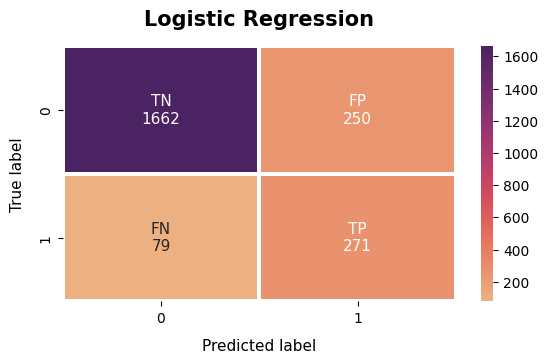

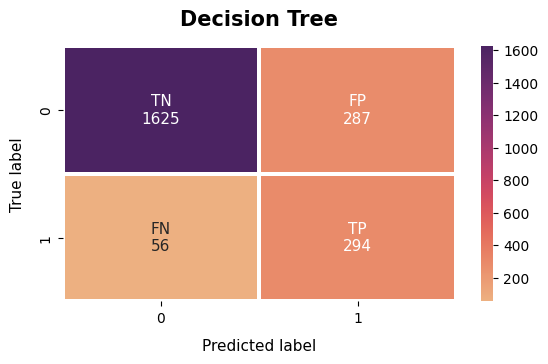

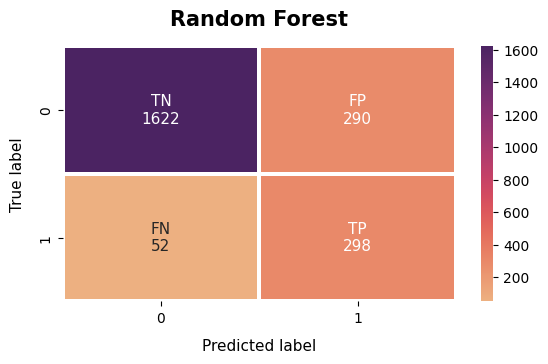

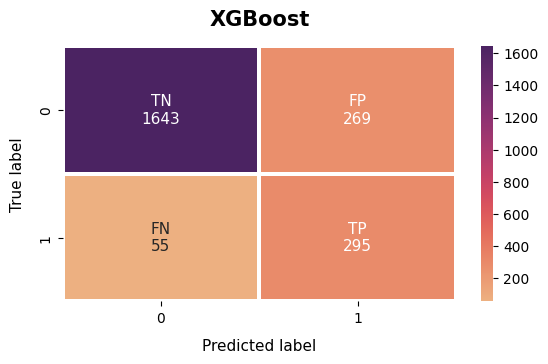

In [47]:
models_to_plot = {
    'Logistic Regression': log_reg_grid.best_estimator_,
    'Decision Tree': dt_grid.best_estimator_,
    'Random Forest': rf_grid.best_estimator_,
    'XGBoost': xgb_grid.best_estimator_
}

for name, model in models_to_plot.items():

    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    # Labels
    labels = np.array([
        ['TN', 'FP'],
        ['FN', 'TP']
    ])

    # Combine labels & counts
    annotated_labels = np.array([
        [f'{labels[i,j]}\n{cm[i,j]}' for j in range(2)]
        for i in range(2)
    ])

    # Plotting
    plt.figure(figsize=(6, 4))

    sns.heatmap(
        cm,
        annot=annotated_labels,
        annot_kws={'size': 11},
        fmt='',
        cmap='flare',
        cbar=True,
        linewidths=1.5,
        linecolor='white'       # adds lines between squares for a clearer visual separation
    )

    plt.title(name, size=15, weight='bold', pad=15)
    plt.xlabel('Predicted label', size=11, labelpad=10)
    plt.ylabel('True label', size=11, labelpad=10)

    plt.tight_layout(pad=2.0)

    plt.show()

### Matrix Analysis

🔹**Results Table**

| **Model** | **TN** | **FP** | **FN** | **TP** |
| --------- | ------ | ------ | ------ | ------ |
| Logistic Regression  | 1662 | 250 | 79 | 271 |
| Decision Tree | 1625 | 287 | 56 | 294 |
| Random Forest | 1622 | 290 | 52 | 298 |
| XGBoost | 1643 | 269 | 55 | 295 |


🔹**Logistic Regression**

The Logistic Regression model produces the highest number of 'false negatives' ($79$), which aligns with its lower recall. This indicates that the model is less effective at identifying purchasing customers.

However, it also produces the fewest 'false positives', meaning it's more conservative in predicting purchases and achieves relatively higher precision.

🔹**Decision Tree** & **XGBoost** 

The Decision Tree and XGBoost models perform similarly in terms of 'false negatives' ($56$ and $55$ respectively), indicating comparable ability to identify purchasing customers.

Although the Decision Tree produces a higher number of false negatives compared to XGBoost. This suggests that XGBoost is more precise, making it a preferable option when minimising 'false positives' is important. 

🔹**Random Forest** 

The Random Forest model produces the lowest number of 'false negatives' ($52$), indicating that it's the most effective at identifying purchasing customers. 

However, this comes at the cost of the highest number of 'false positives' ($290$), meaning it's more likely to incorrectly classify non-purchasing customers as potential buyers. 


🔹**Trade-Off Between Models** 

The comparison highlights a clear trade-off between recall and precision across the models: 

- **Logistic Regression:** lowest recall (misses more buyers), but higher precision (fewer 'false positives')
- **Decision Tree:** improved recall, but increased number of 'false positives'
- **Random Forest:** highest recall (fewest missed buyers), but lower precision (most 'false positives')
- **XGBoost:** most balanced performance (highest F1-score), with relatively high recall and good precision

🔹**Key Insight**

Given the business objective of identifying purchasing customers, minimising false negatives is particularly important. Therefore, models with higher recall, such as Random Forest and XGBoost, are better aligned with the goal. 

---

[Back to Top ⇧](#table-of-contents)

---

## **8. Model Selection**

The final model selection is based on a combination of evaluation metrics, confusion matrix analysis, and alignment with the business objective. 

🔹**Summary of Model Performance**

The tree-based models showed the strongest overall performance, while Logistic Regression provided a simpler but less flexible alternative. 

The confusing matrix analysis revealed a clear trade-off across all of the models: higher recall generally leads to lower precision. This reflects the balance between maximising the identification of purchasing customers and minimising incorrect prediction. 

🔹**Model Selection Decision**

Since the primary objective is to identify as many purchasing customers as possible, *minimising false negatives* is particularly important. 

The Random Forest model produced slightly fewer false negatives than XGBoost, meaning it’s more effective at identifying customers who are likely to make a purchase. Although this results in a higher number of false positives, the cost of these errors is relatively lower in context.

Therefore, the ***Random Forest model*** is selected as the final model, as it combines strong overall performance with the highest recall, making it best aligned with the business objective. 

🔹**Additional Considerations**

In addition to its strong performance, the Random Forest model is less complex than XGBoost, making it easier to interpret and implement.

While XGBoost remains a strong alternative due to its more balanced performance, the slight advantage of Random Forest in identifying purchasing customers makes it the preferred choice in this case. 


In summary, the Random Forest model provides a strong foundation for identifying high-value customers in real time and supporting data-driven decision-making. 

----

[Back to Top ⇧](#table-of-contents)

---

## **9. Feature Importance & Insights**

To better understand which factors influenced purchasing behaviour, feature importance was analysed using the two best-performing models. Feature importance indicates which variables have the greatest impact on the model's predictions. 

### Top 10 Features Plots 

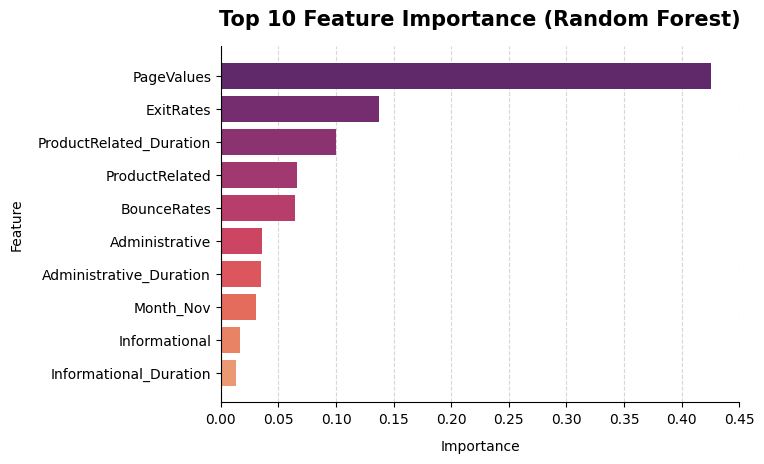

In [48]:
# Random Forest - Top 10 Feature Plot
rf_model = rf_grid.best_estimator_.named_steps['model']

rf_importances = rf_model.feature_importances_
rf_feature_names = X.columns

rf_feature_importance_df = pd.DataFrame({
    'Feature': rf_feature_names,
    'Importance': rf_importances
}).sort_values(by='Importance', ascending=False)


# Top 10 features
rf_top_features = rf_feature_importance_df.head(10)

colours = sns.color_palette('flare_r', len(rf_top_features))

# Plotting
plt.figure(figsize=(8, 5))
plt.barh(rf_top_features['Feature'], rf_top_features['Importance'], color=colours)

plt.gca().invert_yaxis()

# Grid
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.gca().set_axisbelow(True)   # sets the grid lines behind the bars

# Consistent ticks 
plt.xticks(np.arange(0, 0.5, 0.05))

# Consistent formatting
plt.gca().xaxis.set_major_formatter(FormatStrFormatter('%.2f'))

plt.title('Top 10 Feature Importance (Random Forest)', size=15, weight='bold', pad=15)
plt.xlabel('Importance', labelpad=10)
plt.ylabel('Feature', labelpad=10)

sns.despine()

plt.tight_layout(pad=2.0)

plt.show()

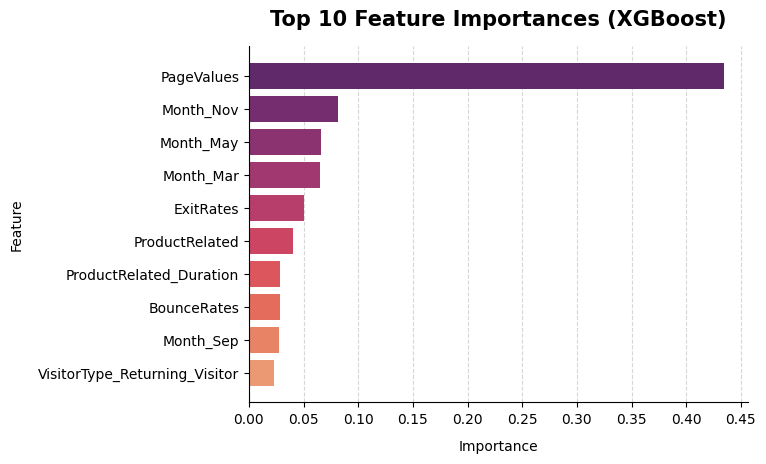

In [49]:
# XGBoost - Top 10 Feature Plot
xgb_model = xgb_grid.best_estimator_.named_steps["model"]

xgb_importances = xgb_model.feature_importances_
xgb_feature_names = X.columns

xgb_feature_importance_df = pd.DataFrame({
    "Feature": xgb_feature_names,
    "Importance": xgb_importances
}).sort_values(by="Importance", ascending=False)

# Top 10 features
xgb_top_features = xgb_feature_importance_df.head(10)

colours = sns.color_palette('flare_r', len(xgb_top_features))

# Plotting
plt.figure(figsize=(8, 5))
plt.barh(xgb_top_features["Feature"], xgb_top_features["Importance"], color=colours)

plt.gca().invert_yaxis()
plt.gca().set_axisbelow(True)   # sets the grid lines behind the bars

# Adding grid lines
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Consistent ticks 
plt.xticks(np.arange(0, 0.5, 0.05))

# Consistent formatting
plt.gca().xaxis.set_major_formatter(FormatStrFormatter('%.2f'))

plt.title("Top 10 Feature Importances (XGBoost)", size=15, weight='bold', pad=15)
plt.xlabel("Importance", labelpad=10)
plt.ylabel('Feature', labelpad=10)

sns.despine()

plt.tight_layout(pad=2.0)

plt.show()

### Feature Importance - Insights 

The feature importance plots show that **PageValues** is by far the most influential feature across both the Random Forest and XGBoost models. This suggests that sessions with higher page value ― indicating meaningful engagement with high-value content ― are strongly associated with purchasing behaviour.

More broadly, several of the most prominent features are related to **customer engagement**, including:

- PageValues
- ExitRates
- Product-related activity

This indicates that customers who spend more time exploring products and interacting with relevant content are more likely to make a purchase.

🔹**Exit Behaviour**

**ExitRates** also play a significant role, particularly in the Random Forest model. Higher exit rates suggest that users leave the website earlier in the session, which is associated with a lower likelihood of purchase.

This highlights the importance of reducing drop-off points in the user journey and improving the overall user experience.


🔹**Additional Insights** (XGBoost)

The XGBoost models highlight additional factors such as **month** and **visitor type**, suggesting that purchasing behaviour may vary depending on the time of year and whether a customer is new or returning.

🔹**Key Insight**

Overall, the result suggests that **customer engagement is the strongest predictor of purchasing behaviour**. Thus, improving how users interact with the website ― such as encouraging deeper exploration and reducing early exits ― may lead to increased conversion rates.

Notably, behavioural features appear to be more influential than static attributes, suggesting that real-time user activity is more informative than demographic or contextual factors.

⚠️ **Important Note**

While feature importance highlights which variables are influential, it does ***not*** indicate whether their effect is positive or negative, nor does it imply causation. These results should therefore be interpreted as ***indicators of association* rather than direct drivers**.

---

[Back to Top ⇧](#table-of-contents)

---

## **10. Presentation for Management**

### Plot for Presentation

**Note**: The code below is not supposed to be part of the presentation - I want a simpler version of the Random Forest feature importance plot.  

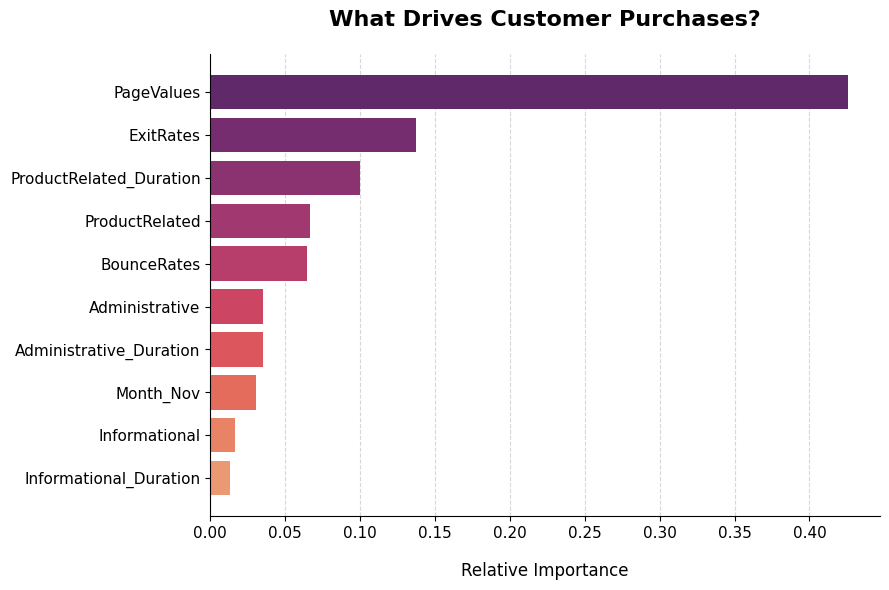

In [50]:
# Top 10 Feature Plot (presentation-friendly version)
#colours[0] = '#d62728'

plt.figure(figsize=(9, 6))

bars = plt.barh(    
    rf_top_features['Feature'],
    rf_top_features['Importance'],
    color=colours       
)   # all of the variables above were defined in the original top 10 feature plot 

plt.gca().invert_yaxis()

# Plot styling
plt.gca().set_axisbelow(True)
plt.grid(axis='x', linestyle='--', alpha=0.5)
sns.despine()

# Bigger and cleaner text
plt.title('What Drives Customer Purchases?', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Relative Importance', fontsize=12, labelpad=15)
plt.ylabel('')      # removed for a cleaner look

# Increased tick size
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()

plt.show()

### Presentation

#### **Objective**

The objective of this analysis was to develop a model capable of predicting whether a customer session will result in a purchase. This enables the company to better understand customer behaviour and identify high-value customers in real time.

---

#### **Key Findings**

The analysis shows that **customer engagement is the strongest driver of purchasing behaviour**. Customers who actively interact with the websit e—particularly by viewing high-value pages and exploring products— are significantly more likely to make a purchase.

In contrast, sessions with high exit rates are less likely to result in a purchase, indicating that early drop-off points in the user journey represent lost opportunities.

Notably, ***what* customers do during a session is more important than who they are or where they are**. Behavioural factors, such as interaction with content and products, are more predictive than static attributes such as location or browser.

---

#### **Feature Importance Plot**

![Feature Importance Plot](rf_feature_importance_plot_presentation.png)

This chart highlights the most important factors influencing whether a customer makes a purchase.

As shown, engagement-related features —particularly **PageValues**— are by far the strongest predictors. This confirms that customers who interact with high-value content are significantly more likely to convert.

Feature importance indicates which variables are influential, but it does not imply causation. The results should therefore be interpreted as indicators of association rather than definitive drivers of behaviour.

---

#### **Model Recommendation**

The **Random Forest model** is recommended for implementation, as it is the most effective at identifying customers who are likely to make a purchase, directly aligning with the primary business objective.

**Key Strenght**

The model’s strongest advantage is its ability to identify a high proportion of purchasing customers, reducing the likelihood of missing valuable opportunities.

**Key Trade-Off**

This improved sensitivity comes at the cost of identifying some non-purchasing customers as potential buyers.

In this context, this trade-off is acceptable, as the cost of missing a potential customer is considered higher than the cost of targeting a non-buyer.

While some alternative models were more conservative and produced fewer false positives, they also missed more purchasing customers. The Random Forest model provides the best balance for this use case.

---

#### **General Limitations**

The model is based on historical data and may not capture all factors influencing customer behaviour.

Additionally, feature importance identifies influential variables but does not imply causation. As with all predictive models, results should be interpreted as probabilities rather than certainties, and the model should be used as a decision-support tool.

Despite these limitations, the model provides valuable insights and can be effectively used to support decision-making in practice. 

---

#### **Practical Application**

The model can be used in real time to monitor ongoing customer sessions and identify users who are more likely to make a purchase.

These users can then be prioritised for enhanced experiences, such as:

- Personalised recommendations
- Streamlined checkout processes
- Targeted assistance or support  

--- 

#### **Final Insight**

Improving customer engagement —particularly by encouraging deeper product exploration and reducing early exits— has strong potential to increase conversion rates.

---

[Back to Top ⇧](#table-of-contents)

---
